# Bayesian BLP on the Nevo (2000) Cereal Panel

This notebook applies `BayesianBLP` to the canonical aggregate-share demand dataset from Nevo's *"A Practitioner's Guide to Estimation of Random Coefficients Logit Models of Demand"*. It is the standard teaching example for BLP-style structural demand estimation: 24 ready-to-eat cereal brands across 47 US cities × 2 quarters, with prices, two product characteristics (sugar content, mushy indicator), and 20 cost / BLP-style instruments.

We will:

1. Load and clean the public Nevo panel.
2. Synthesize the outside-good rows (Nevo's data does not ship with one).
3. Fit `BayesianBLP` with `nutpie` on a tractable subset of cities.
4. Diagnose the posterior geometry — divergences, tree-depth saturation,
   energy plot, pair plots — to identify what is making sampling expensive.
5. Inspect own-price elasticities (the headline output) and run two
   counterfactuals: a panel-wide price hike and a time-targeted one.
6. Translate the diagnostic findings into concrete recommendations for
   speeding up future fits on the full panel.

**Note on the data.** Nevo (2000) explicitly states that the Practitioner's Guide dataset is *simulated data calibrated to the cereal market*, not actual scanner data. The real empirical results are in the companion paper (Nevo 2001, Econometrica). We use the simulated panel here because it is the standard teaching example.


In [1]:
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pymc_marketing.customer_choice import BayesianBLP

warnings.filterwarnings("ignore")
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 4]
plt.rcParams["figure.dpi"] = 110
%config InlineBackend.figure_format = 'retina'

## 1. Load and inspect the Nevo panel

The CSV ships with European decimal formatting (`","` as the decimal separator), so we pass `decimal=","` to `pd.read_csv`. The raw layout is *inside-products only* — the outside good's share is implicit, equal to `1 - sum(inside_shares)` per market.


In [2]:
raw = pd.read_csv("../../../../data/data_nevo.csv", decimal=",")

# Compose city x quarter -> (region, period). The original file has only
# year=88 and quarters 1, 2, so 47 cities x 2 quarters = 94 markets.
raw["period"] = raw["year"].astype(int) * 4 + raw["quarter"].astype(int)
raw["region"] = "c" + raw["city"].astype(str)
raw["market"] = raw["region"] + "_" + raw["period"].astype(str)
# Decode firm codes to readable names
FIRM_NAMES = {
    1: "Kelloggs",
    2: "GenMills",
    3: "Post",
    4: "Quaker",
    6: "Ralston",
}
raw["firm_name"] = raw["firm"].map(FIRM_NAMES)
raw["product"] = raw["firm_name"] + "_" + raw["brand"].astype(int).astype(str)

print(f"Rows: {len(raw)}")
print(f"Brands: {raw['firmbr'].nunique()}")
print(f"Cities: {raw['city'].nunique()}")
print(f"Quarters: {sorted(raw['quarter'].unique())}")
print(f"Markets (city × period): {raw.groupby(['city', 'period']).ngroups}")

market_share_sums = raw.groupby("market")["share"].sum()
print(
    f"\nInside-share sum per market: "
    f"mean={market_share_sums.mean():.3f}, "
    f"min={market_share_sums.min():.3f}, "
    f"max={market_share_sums.max():.3f}"
)
print(
    "→ Outside-good share averages "
    f"~{1 - market_share_sums.mean():.2f}; "
    "we synthesize one outside row per market below."
)
raw.head(4)

Rows: 2256
Brands: 24
Cities: 47
Quarters: [np.int64(1), np.int64(2)]
Markets (city × period): 94

Inside-share sum per market: mean=0.476, min=0.185, max=0.696
→ Outside-good share averages ~0.52; we synthesize one outside row per market below.


,id,firmbr,firm,brand,city,year,quarter,share,price,sugar,...,z16,z17,z18,z19,z20,period,region,market,firm_name,product
0,100401880,1004,1,4,1,88,1,0.0124,0.072,2.0,...,0.067,0.068,0.035,0.126,0.035,353,c1,c1_353,Kelloggs,Kelloggs_4
1,100601880,1006,1,6,1,88,1,0.0078,0.114,18.0,...,0.088,0.111,0.088,0.050,0.073,353,c1,c1_353,Kelloggs,Kelloggs_6
2,100701880,1007,1,7,1,88,1,0.0130,0.132,4.0,...,0.112,0.108,0.086,0.122,0.102,353,c1,c1_353,Kelloggs,Kelloggs_7
3,100901880,1009,1,9,1,88,1,0.0058,0.130,3.0,...,0.088,0.102,0.102,0.111,0.104,353,c1,c1_353,Kelloggs,Kelloggs_9


## 2. Build the `BayesianBLP` input

Three transformations:

1. **Subset**. The full 94-market × 24-brand panel produces a 2256-cell `xi_tilde` block whose joint geometry with `(ρ, σ_ξ)` makes a CPU fit expensive (≈15 min). We subset to 8 cities × 2 quarters = 16 markets so the notebook fits in a few minutes; the methodology is identical at full scale.

2. **Rescale price.** Nevo's published price scale is "share of category dollar sales per serving" (≈0.05–0.22). The default `α ~ Normal(0, 2)` prior in `BayesianBLP` assumes a unit-variance-ish price scale, so on the raw Nevo scale the implied `α·p` term in utility is too small and the posterior collapses to near-zero own-price elasticities. We multiply price by 100 (cents) so |α| naturally lands in the prior support.

3. **Synthesize outside rows.** One row per market and time, `share = 1 - Σ(inside)`, all characteristics / instruments / price set to zero — matching the convention used by the synthetic-data generator.


In [3]:
N_CITIES_DEMO = 8
# INSTRUMENTS = ["z6", "z7", "z8", "z9", "z10"]  # BLP-style rival-characteristic sums
INSTRUMENTS = [f"z{i}" for i in range(1, 21)]

# Subset to N_CITIES_DEMO cities x 2 quarters x 24 brands.
keep_cities = sorted(raw["city"].unique())[:N_CITIES_DEMO]
df_inside = raw[raw["city"].isin(keep_cities)].copy()
df_inside["price"] = df_inside["price"] * 100.0  # to cents

# Synthesize outside-good rows
market_share_sum = df_inside.groupby("market")["share"].sum()
outside_share = 1.0 - market_share_sum
market_meta = df_inside.drop_duplicates("market").set_index("market")[
    ["region", "period"]
]

outside = pd.DataFrame(
    {
        "market": outside_share.index,
        "product": "outside",
        "share": outside_share.values,
        "price": 0.0,
        "sugar": 0.0,
        "mushy": 0.0,
        **{c: 0.0 for c in INSTRUMENTS},
    }
)
outside["region"] = market_meta.reindex(outside["market"])["region"].values
outside["period"] = market_meta.reindex(outside["market"])["period"].values

# n_jt is required by the heteroskedastic-Normal log-share-ratio likelihood
# but Nevo's data does not include serving counts; use a plausible constant
# (it only enters the per-cell variance scaling).
df_inside["n"] = 1000
outside["n"] = 1000

df = pd.concat([df_inside, outside], ignore_index=True, sort=False)

assert np.allclose(df.groupby("market")["share"].sum(), 1.0, atol=1e-6)  # noqa: S101
print(
    f"Final long-format frame: {len(df)} rows "
    f"(= {df['market'].nunique()} markets x {df['product'].nunique()} products)"
)
df[
    ["market", "region", "period", "product", "share", "price", "sugar", "mushy", "n"]
].head(6)

Final long-format frame: 400 rows (= 16 markets x 25 products)


,market,region,period,product,share,price,sugar,mushy,n
0,c1_353,c1,353,Kelloggs_4,0.0124,7.2,2.0,1.0,1000
1,c1_353,c1,353,Kelloggs_6,0.0078,11.4,18.0,1.0,1000
2,c1_353,c1,353,Kelloggs_7,0.0130,13.2,4.0,1.0,1000
3,c1_353,c1,353,Kelloggs_9,0.0058,13.0,3.0,0.0,1000
4,c1_353,c1,353,Kelloggs_11,0.0179,15.5,12.0,0.0,1000
5,c1_353,c1,353,Kelloggs_13,0.0266,13.7,14.0,0.0,1000


## 3. Construct and fit the model

We declare `region_col="region"` and `time_col="period"` so cities pool hierarchically on `α_r`, and the period coordinate is exposed for time-targeted counterfactuals. The five instruments enable the conditional decomposition `ξ̃ | η ~ N(ρ·σ_ξ/σ_η · η, σ_ξ·√(1-ρ²))` that corrects for price endogeneity — Nevo's headline empirical concern.

In [4]:
from pymc_extras.prior import Prior

model = BayesianBLP(
    market_data=df,
    characteristics=["sugar", "mushy"],
    instruments=INSTRUMENTS,
    region_col="region",
    time_col="period",
    random_coef_on=["price"],
    n_mc_draws=100,
    model_config={
        "sigma_xi": Prior("HalfNormal", sigma=0.5),
        "sigma_xi_j": Prior("HalfNormal", sigma=0.25),
        "alpha": Prior("Normal", mu=0.0, sigma=3.0),  # Slightly wider prior
    },
    random_seed=0,
    hierarchical_parameterisation="noncentered",
)
print(
    f"M={model._M} markets, J={model._J} inside products, "
    f"R={len(model._regions)} regions, T={model._T} periods, "
    f"K={model._K} characteristics, L={model._L} instruments"
)

M=16 markets, J=24 inside products, R=8 regions, T=2 periods, K=2 characteristics, L=20 instruments


In [ ]:
t0 = time.perf_counter()
model.fit(
    nuts_sampler="nutpie",
    draws=2000,
    tune=1000,
    chains=4,
    target_accept=0.95,
    progressbar=True,
    init="adapt_full",
    random_seed=0,
)
elapsed = time.perf_counter() - t0
n_div = int(model.idata.sample_stats["diverging"].sum())
print(f"\nFit took {elapsed:.0f}s ({elapsed / 60:.1f} min). Divergences: {n_div}")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.07,127
,3000,0,0.08,63
,3000,0,0.08,63
,3000,0,0.08,63



Fit took 138s (2.3 min). Divergences: 0


## 4. Posterior diagnostics


In [19]:
# a) Headline summary on the parameters that drive predictions
az.summary(
    model.idata,
    var_names=[
        "alpha_pop",
        "beta_pop",
        "tau_alpha",
        "sigma_random",
        "rho_price_xi",
        "sigma_xi",
        "sigma_xi_j",
    ],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_pop,-0.337,0.030,-0.391,-0.281,0.002,0.001,336.0,663.0,1.01
beta_pop[sugar],0.061,0.026,0.011,0.108,0.002,0.001,298.0,708.0,1.00
beta_pop[mushy],-0.098,0.329,-0.715,0.516,0.015,0.008,464.0,830.0,1.01
tau_alpha,0.062,0.024,0.027,0.106,0.001,0.001,479.0,1086.0,1.01
sigma_random[price],0.131,0.024,0.087,0.176,0.001,0.000,633.0,1204.0,1.00
rho_price_xi,0.300,0.068,0.174,0.428,0.002,0.001,1362.0,2323.0,1.00
sigma_xi,0.708,0.035,0.640,0.771,0.001,0.001,1438.0,2345.0,1.00
sigma_xi_j,0.744,0.091,0.578,0.914,0.003,0.002,867.0,2025.0,1.00


**Read this table for two things:**

- `r_hat` close to 1 (≤ 1.02 ideal). Values 1.05–1.20 indicate chains that haven't fully mixed — for a tutorial fit with 2 chains × 1500 steps this is acceptable, but for production inference you would run 4 chains × 2000 draws.
- `ess_bulk` should be ≥ 100 for parameters you want to report. The characteristic coefficients (`beta_pop[sugar]`, `beta_pop[mushy]`) often have lower ESS than `alpha_pop` here — this is structural: there are only J=24 brand-level draws of each characteristic per market, vs J×R = 24×R draws of price.


## 5. Endogeneity correction: IV vs no-IV

The headline feature of BLP is the price-endogeneity correction. When prices are set by firms that observe demand shocks $\xi$, the price coefficient $\alpha$ is biased toward zero without instruments. We re-fit the model dropping all instruments to show the bias.


In [ ]:
# Fit without instruments to show endogeneity bias
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_noiv = BayesianBLP(
        market_data=df,
        characteristics=["sugar", "mushy"],
        instruments=None,
        random_coef_on=["price"],
        n_mc_draws=100,
        model_config={
            "sigma_xi": Prior("HalfNormal", sigma=0.5),
            "sigma_xi_j": Prior("HalfNormal", sigma=0.25),
            "alpha": Prior("Normal", mu=0.0, sigma=3.0),
        },
        random_seed=0,
        hierarchical_parameterisation="noncentered",
    )

model_noiv.fit(
    nuts_sampler="nutpie",
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.95,
    progressbar=True,
    init="adapt_full",
    random_seed=0,
)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.09,127
,2000,0,0.10,63
,2000,0,0.10,31
,2000,0,0.10,127


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

Warmup iterations saved (warmup_*).

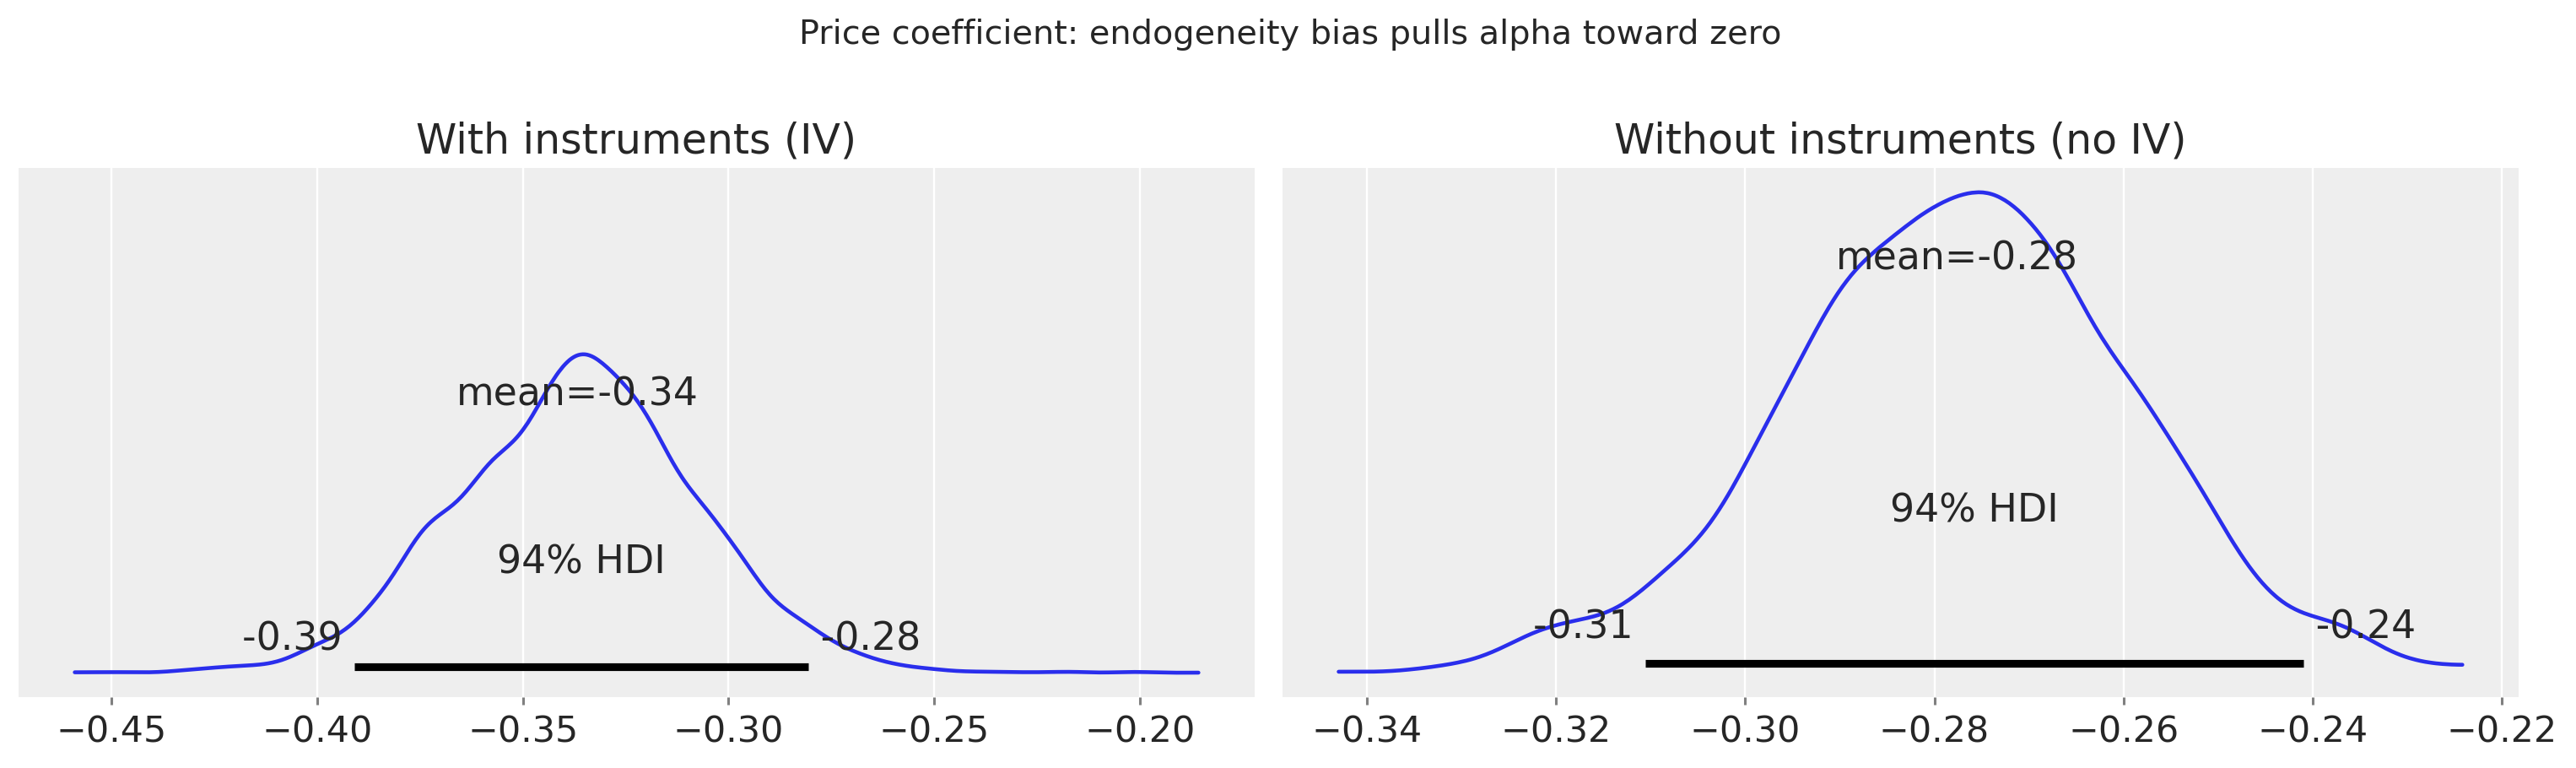

IV posterior mean:    -0.337
no-IV posterior mean: -0.278
Bias toward zero:    0.059

Without instruments the model underestimates price sensitivity,
producing unrealistically small elasticities.


In [24]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

az.plot_posterior(
    model.idata,
    var_names=["alpha_pop"],
    ax=axs[0],
)
axs[0].set_title("With instruments (IV)")

az.plot_posterior(
    model_noiv.idata,
    var_names=["alpha"],
    ax=axs[1],
)
axs[1].set_title("Without instruments (no IV)")

plt.suptitle(
    "Price coefficient: endogeneity bias pulls alpha toward zero",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

iv_mean = float(model.idata.posterior["alpha_pop"].mean())
noiv_mean = float(model_noiv.idata.posterior["alpha"].mean())
print(f"IV posterior mean:    {iv_mean:.3f}")
print(f"no-IV posterior mean: {noiv_mean:.3f}")
print(f"Bias toward zero:    {abs(iv_mean) - abs(noiv_mean):.3f}")
print("\nWithout instruments the model underestimates price sensitivity,")
print("producing unrealistically small elasticities.")

Note that $\alpha$ is estimated on the cents scale (price × 100); multiply by 100 to recover the dollar-scale coefficient comparable to Nevo's $\alpha \sim$ −30."

## 6. Own-price elasticities and counterfactuals

The headline test of any BLP demand estimator: do own-price elasticities land in a *plausible* range? For ready-to-eat cereal Nevo and the wider literature put the typical own-price elasticity in `[-2, -4]`.


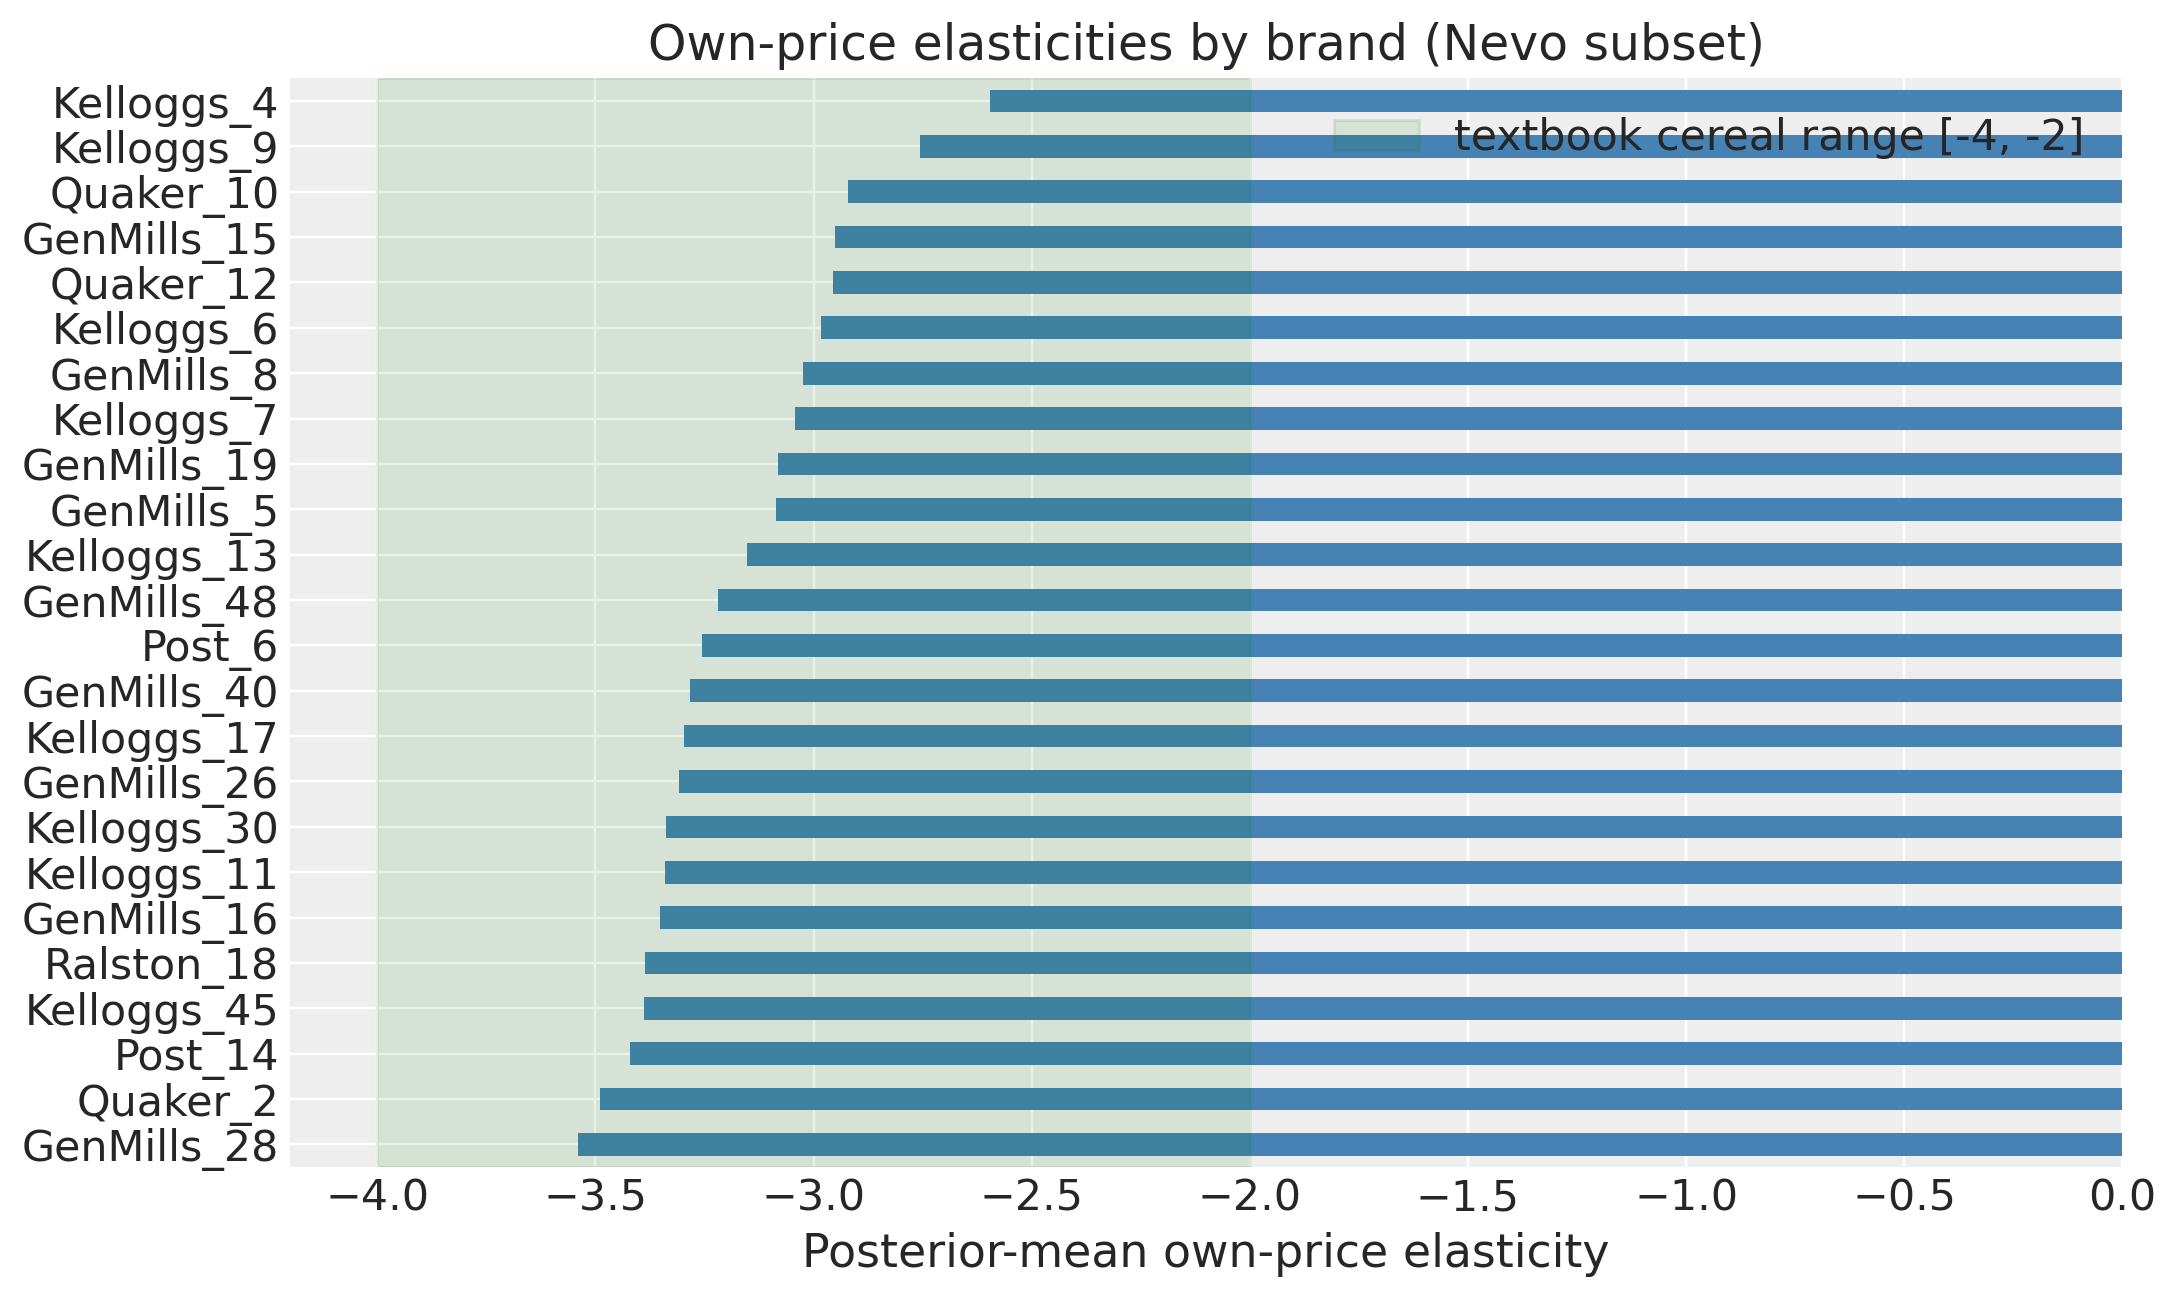

Range: [-3.541, -2.597]. Median: -3.237.


In [25]:
elast = model.elasticities(at="mean", n_samples=400)
own_eps = pd.Series(
    {
        pname: float(elast.values[:, j, j].mean())
        for j, pname in enumerate(model._inside_products)
    }
).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
own_eps.plot(kind="barh", ax=ax, color="steelblue")
ax.axvspan(-4, -2, color="green", alpha=0.1, label="textbook cereal range [-4, -2]")
ax.set_xlabel("Posterior-mean own-price elasticity")
ax.set_title("Own-price elasticities by brand (Nevo subset)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Range: [{own_eps.min():.3f}, {own_eps.max():.3f}]. "
    f"Median: {own_eps.median():.3f}."
)

In [26]:
# Counterfactual: 10% price hike on the largest brand, panel-wide
target = own_eps.idxmin()  # most elastic — biggest expected response
print(f"Applying a 10% price hike to {target} (own-ε = {own_eps[target]:.2f})")

baseline = model.counterfactual_shares(price_change=None, n_samples=400)
shocked = model.counterfactual_shares(price_change={target: 0.10}, n_samples=400)

base_s = baseline["s_inside"].mean(dim="sample").values
shocked_s = shocked["s_inside"].mean(dim="sample").values
delta = shocked_s - base_s

j_target = model._inside_products.index(target)
print(f"\nMarket-average share of {target}:")
print(f"  baseline: {base_s[:, j_target].mean():.4f}")
print(f"  shocked:  {shocked_s[:, j_target].mean():.4f}")
print(f"  Δ:        {delta[:, j_target].mean():+.4f}")

# Where did the lost share go? Top rivals + outside good.
delta_outside = (
    shocked["s_outside"].mean(dim="sample") - baseline["s_outside"].mean(dim="sample")
).values.mean()
rival_changes = pd.Series(
    {
        pname: float(delta[:, j].mean())
        for j, pname in enumerate(model._inside_products)
        if pname != target
    }
).sort_values(ascending=False)

print("\nLargest gainers among rivals (top 5):")
print(rival_changes.head().to_string())
print(f"\nOutside-good Δshare: {delta_outside:+.4f}")

Applying a 10% price hike to GenMills_28 (own-ε = -3.54)

Market-average share of GenMills_28:
  baseline: 0.0219
  shocked:  0.0154
  Δ:        -0.0065

Largest gainers among rivals (top 5):
Kelloggs_11    0.000521
Kelloggs_6     0.000518
GenMills_19    0.000281
GenMills_8     0.000262
GenMills_5     0.000255

Outside-good Δshare: +0.0024


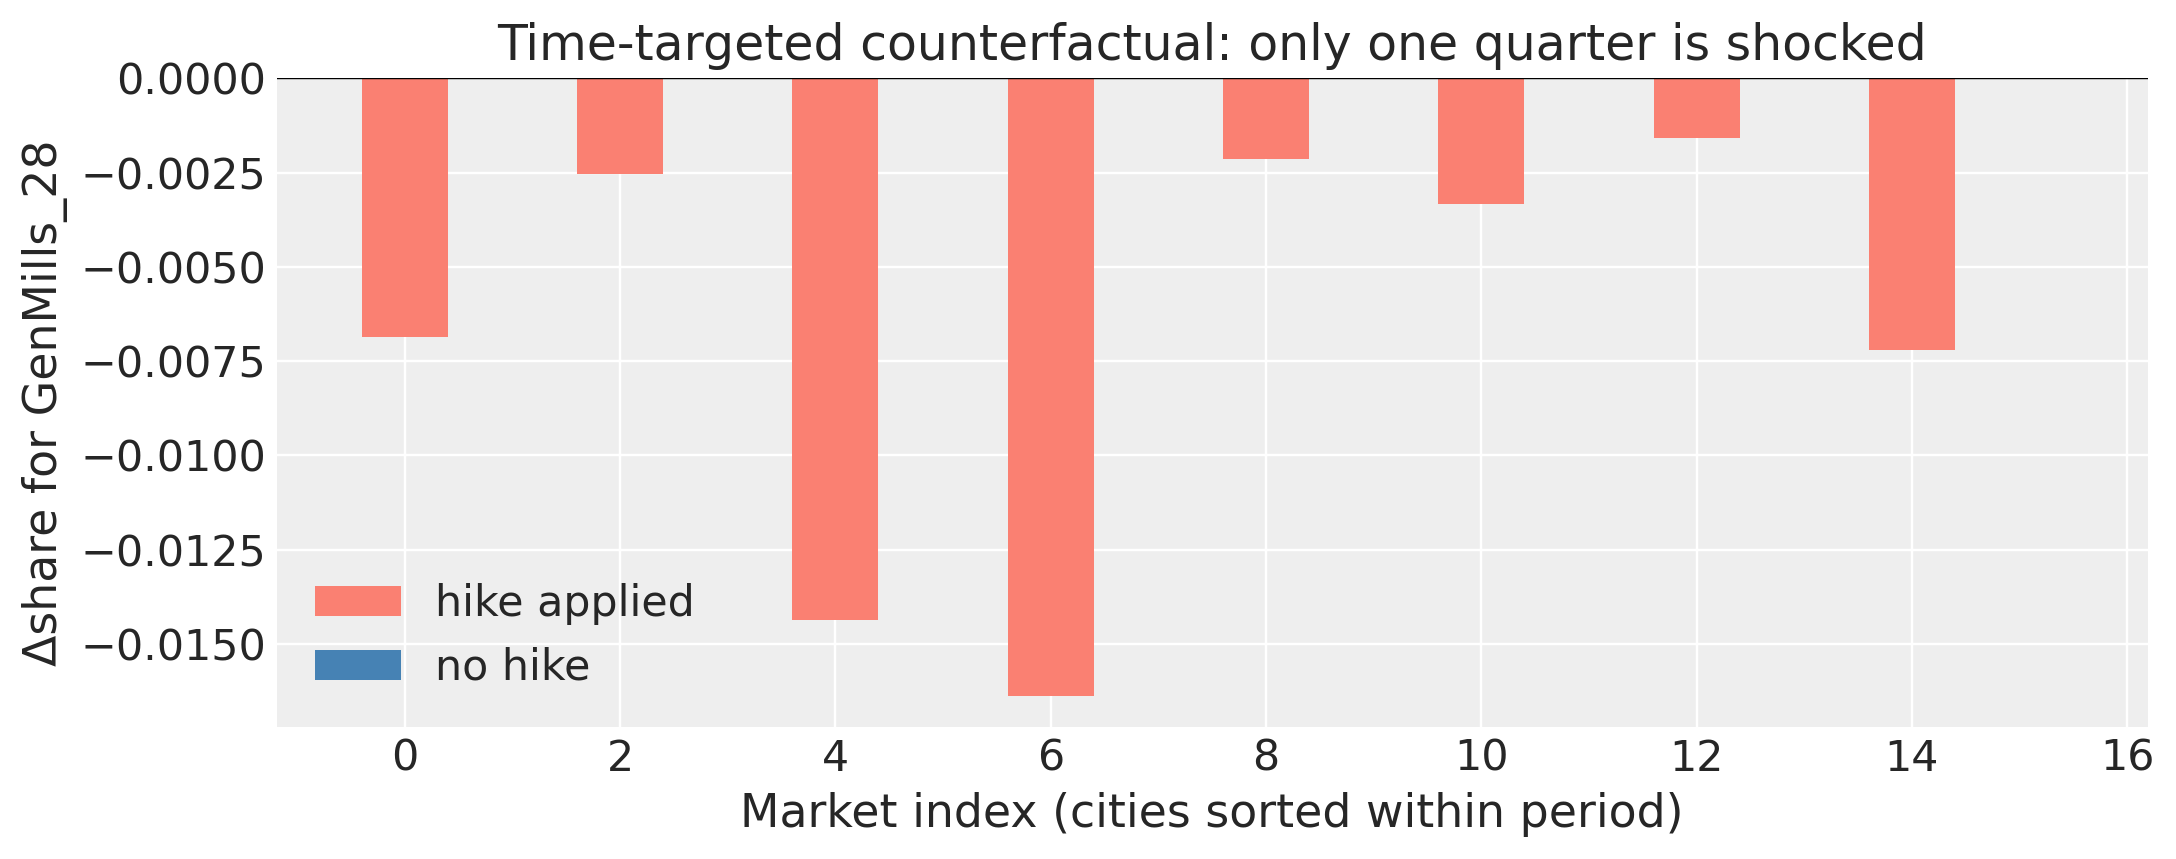


In period 353: mean Δ = -0.0068
Outside period 353: max |Δ| = 0.00e+00 (must be exactly zero — sanity check that the mask is correct)


In [27]:
# Time-targeted counterfactual: same hike, but applied only in period 1.
period_target = sorted(df["period"].unique())[0]
shocked_q = model.counterfactual_shares(
    price_change={target: 0.10}, periods=[period_target], n_samples=400
)

period_coord = shocked_q.coords["period"].values
in_window = period_coord == period_target

delta_in = (
    (shocked_q["s_inside"] - baseline["s_inside"])
    .mean(dim="sample")
    .values[:, j_target]
)

fig, ax = plt.subplots(figsize=(10, 4))
markets = np.arange(model._M)
ax.bar(markets[in_window], delta_in[in_window], color="salmon", label="hike applied")
ax.bar(markets[~in_window], delta_in[~in_window], color="steelblue", label="no hike")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Market index (cities sorted within period)")
ax.set_ylabel(f"Δshare for {target}")
ax.set_title("Time-targeted counterfactual: only one quarter is shocked")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nIn period {period_target}: mean Δ = {delta_in[in_window].mean():+.4f}")
print(
    f"Outside period {period_target}: max |Δ| = {np.abs(delta_in[~in_window]).max():.2e} "
    "(must be exactly zero — sanity check that the mask is correct)"
)

## 7. Taste profiles across markets

The model integrates over consumer taste types to predict aggregate shares. Having fit the posterior, we reverse the question: which taste types does each market rely on? The stacked area chart below shows how each consumer type ($\nu < 0$ = more price-sensitive, $\nu > 0$ = less) allocates across cereal brands.


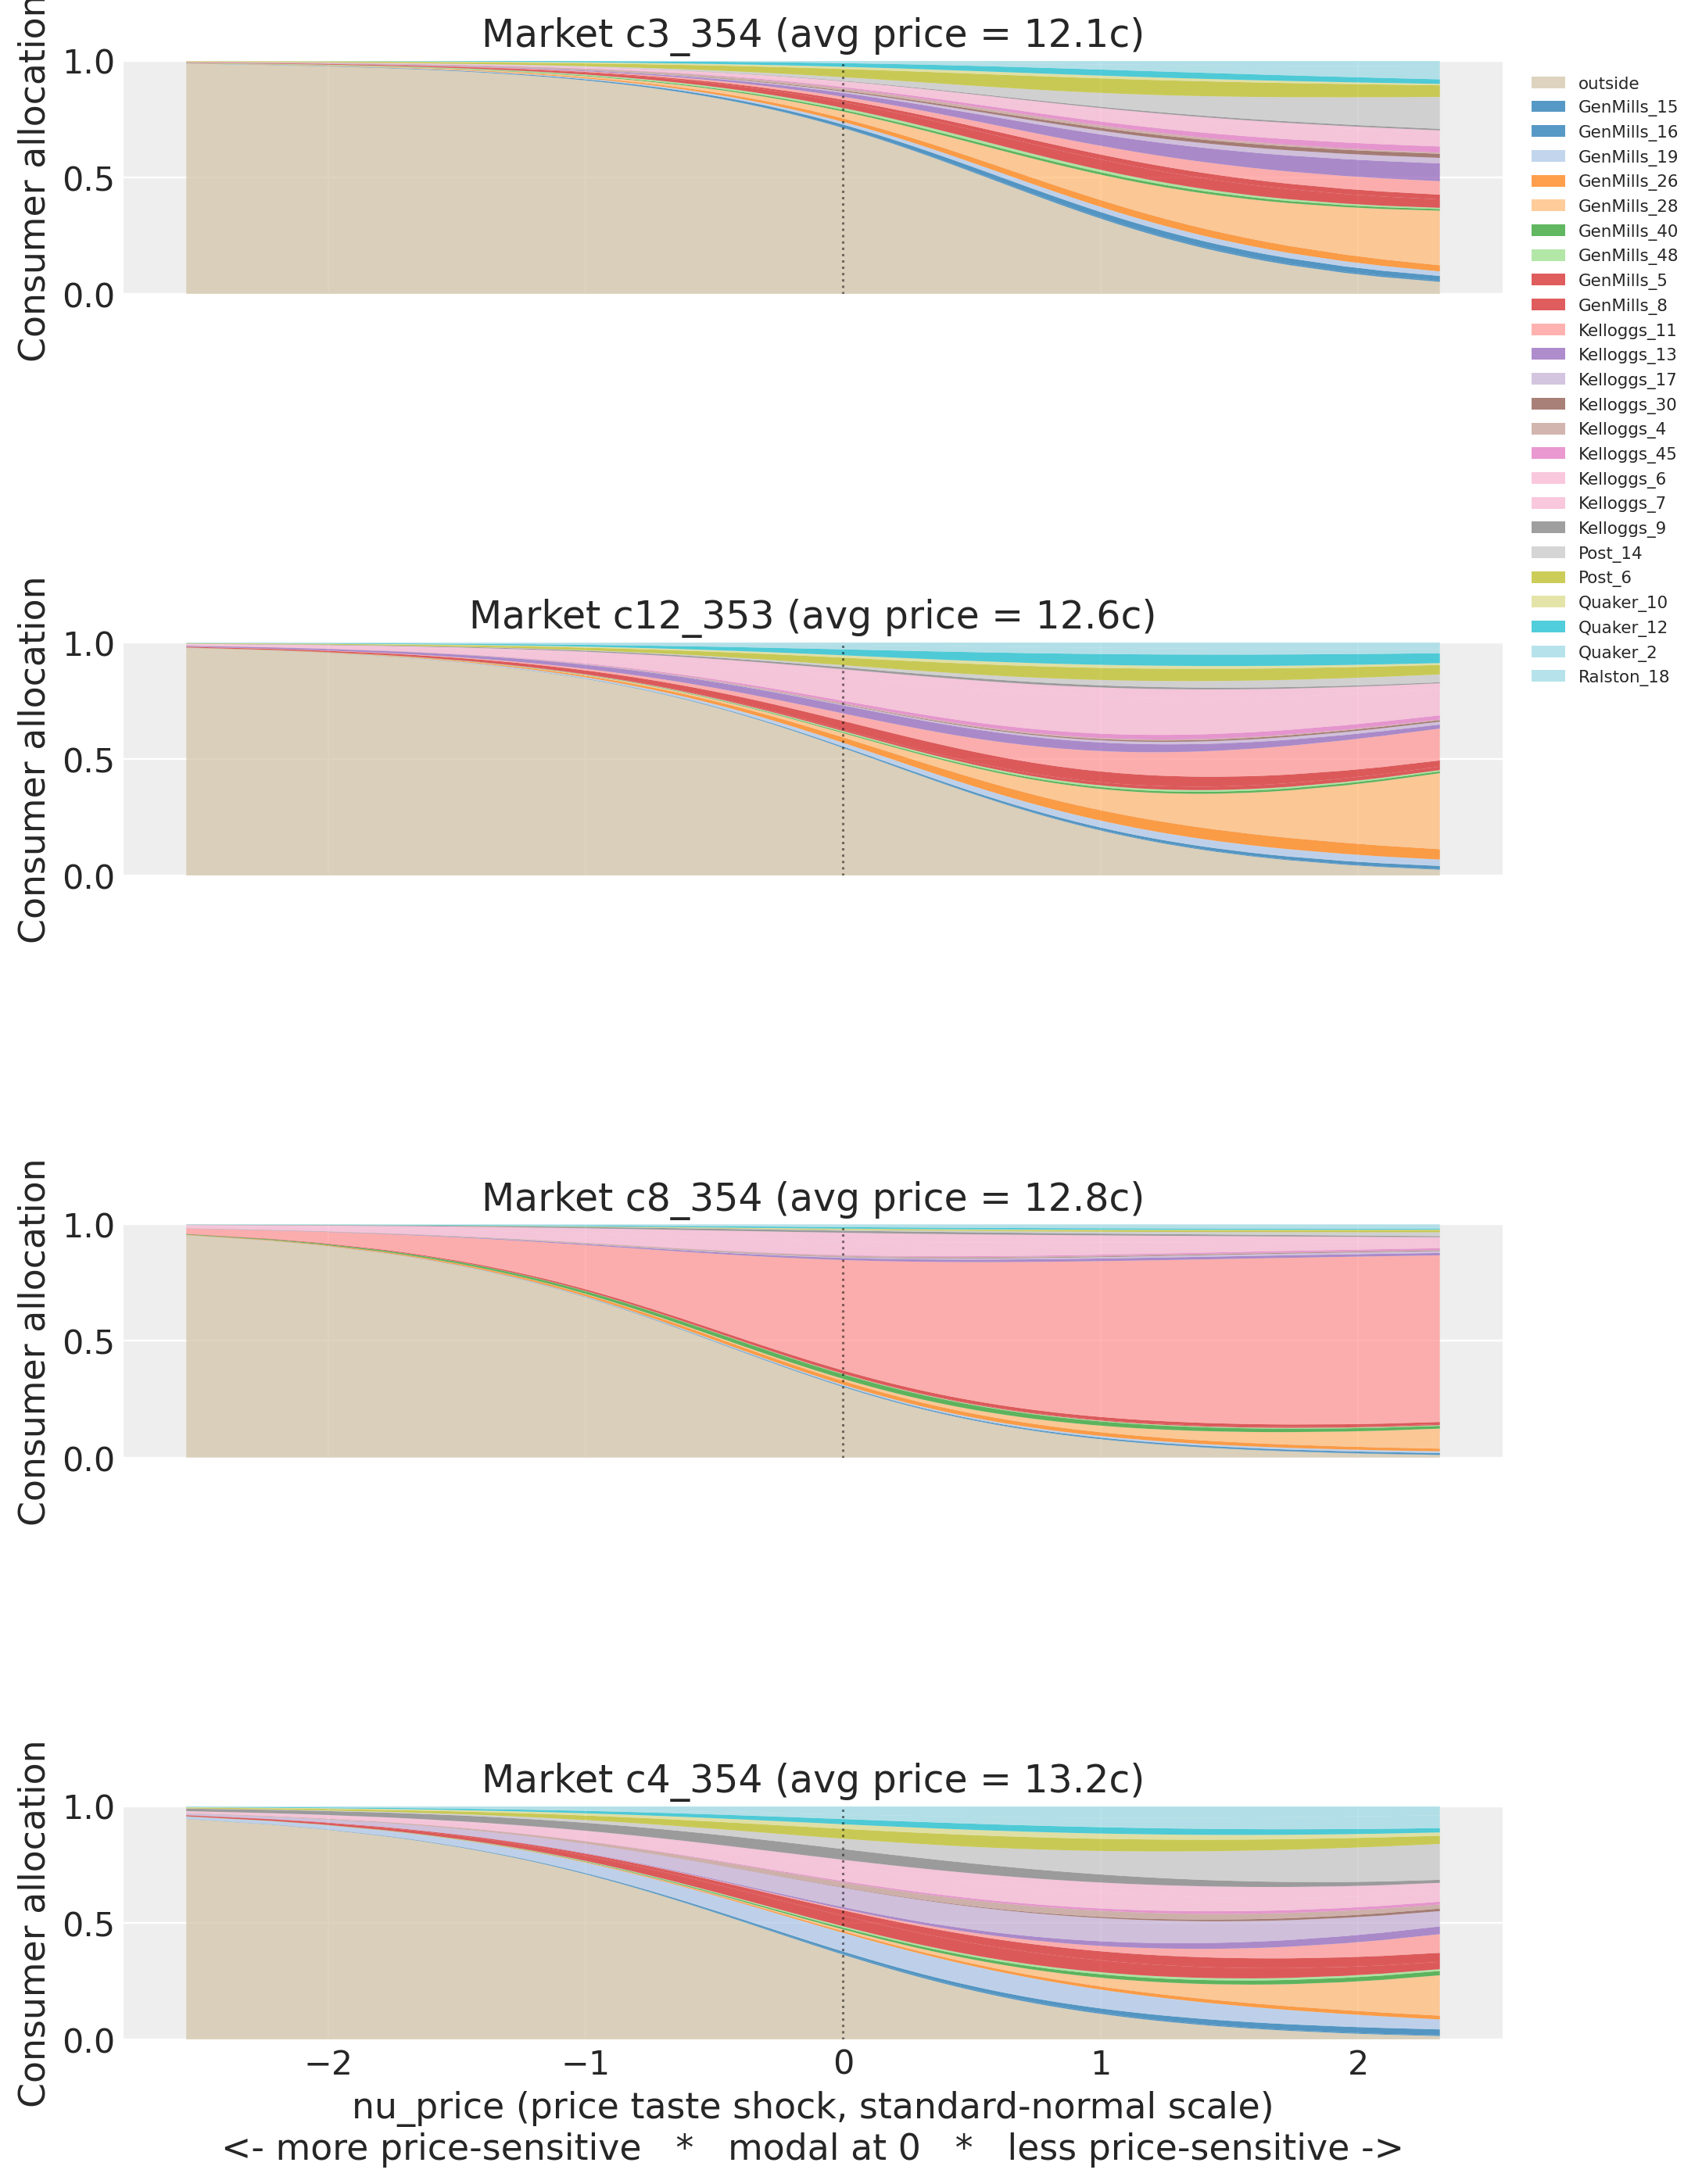

In [28]:
def plot_taste_profile_stacked(model, market_indices=None, n_samples=200):
    """Stacked area chart of consumer allocation across the nu_price axis."""
    if market_indices is None:
        market_indices = list(range(min(4, model._M)))

    # Draw posterior parameter sets, then compute per-consumer-type choice probs.
    alpha_M, beta_M, xi_M, sigma_M = model._iterate_posterior_samples(n_samples)
    s_per_draw, _, s_out_per_draw, *_ = model._batch_shares(
        alpha_M, beta_M, xi_M, sigma_M, model._price
    )
    s_avg = s_per_draw.mean(axis=0)  # (M, J, R)
    s_out_avg = s_out_per_draw.mean(axis=0)  # (M, R)

    nu = model._halton[: model.n_mc_draws, 0]
    order = np.argsort(nu)
    nu_sorted = nu[order]

    n = len(market_indices)
    _fig, axes = plt.subplots(n, 1, figsize=(10, 3.2 * n), sharex=True)
    if n == 1:
        axes = [axes]

    outside_color = "#d4c5a9"
    # With 24 brands, use a colormap instead of the default prop_cycle
    cmap = plt.cm.get_cmap("tab20", model._J)
    inside_colors = [cmap(j) for j in range(model._J)]

    for ax, m_idx in zip(axes, market_indices, strict=True):
        stacks = [
            s_out_avg[m_idx, order],
            *[s_avg[m_idx, j, order] for j in range(model._J)],
        ]
        labels = ["outside", *model._inside_products]
        colors = [outside_color, *inside_colors]
        ax.stackplot(nu_sorted, *stacks, labels=labels, colors=colors, alpha=0.75)
        ax.axvline(0, color="black", linestyle=":", lw=1, alpha=0.5)
        ax.set_ylim(0, 1)
        ax.set_ylabel("Consumer allocation")
        avg_p = float(model._price[m_idx].mean())
        ax.set_title(f"Market {model._markets[m_idx]} (avg price = {avg_p:.1f}c)")
        # Only show legend for first panel (24 brands is a lot)
        if ax is axes[0]:
            ax.legend(
                loc="upper left",
                bbox_to_anchor=(1.01, 1),
                fontsize=7,
                ncol=1,
            )

    axes[-1].set_xlabel(
        "nu_price (price taste shock, standard-normal scale)\n"
        "<- more price-sensitive   *   modal at 0   *   less price-sensitive ->"
    )
    plt.tight_layout()
    plt.show()


# Pick 4 markets spanning the price range
_avg_p = model._price.mean(axis=1)
_order = np.argsort(_avg_p)
_picks = [
    int(_order[0]),
    int(_order[len(_order) // 3]),
    int(_order[2 * len(_order) // 3]),
    int(_order[-1]),
]
plot_taste_profile_stacked(model, market_indices=_picks)

In [29]:
import pandas as pd


def taste_type_demand_share(model, n_samples=200):
    """Share of inside-good demand contributed by each taste-type bucket."""
    alpha_M, beta_M, xi_M, sigma_M = model._iterate_posterior_samples(n_samples)
    s_per_draw, _, _, _, _ = model._batch_shares(
        alpha_M, beta_M, xi_M, sigma_M, model._price
    )
    s_avg = s_per_draw.mean(axis=(0, 2))  # (M, R)

    nu = model._halton[: model.n_mc_draws, 0]
    sensitive = nu < -1.0
    insensitive = nu > 1.0
    modal = ~sensitive & ~insensitive

    rows = []
    for m in range(model._M):
        total = s_avg[m].sum()
        rows.append(
            {
                "market": model._markets[m],
                "avg_price": float(model._price[m].mean()),
                "sensitive_pct": s_avg[m, sensitive].sum() / total,
                "modal_pct": s_avg[m, modal].sum() / total,
                "insensitive_pct": s_avg[m, insensitive].sum() / total,
            }
        )
    return pd.DataFrame(rows)


profiles = taste_type_demand_share(model, n_samples=200)

nu = model._halton[: model.n_mc_draws, 0]
baseline = {
    "sensitive": f"{(nu < -1).mean():.2f}",
    "modal": f"{((nu >= -1) & (nu <= 1)).mean():.2f}",
    "insensitive": f"{(nu > 1).mean():.2f}",
}

print("Share of inside-good demand by taste-type bucket:\n")
print(profiles.to_string(index=False, float_format=lambda x: f"{x:6.3f}"))
print(f"\nHomogeneous baseline (flat logit): {baseline}")

Share of inside-good demand by taste-type bucket:

 market  avg_price  sensitive_pct  modal_pct  insensitive_pct
 c1_353     13.171          0.027      0.660            0.312
 c1_354     12.892          0.039      0.675            0.285
c11_353     12.588          0.039      0.671            0.290
c11_354     13.100          0.029      0.658            0.313
c12_353     12.579          0.031      0.666            0.303
c12_354     12.171          0.037      0.666            0.297
 c3_353     12.587          0.028      0.649            0.322
 c3_354     12.071          0.023      0.613            0.365
 c4_353     12.075          0.060      0.713            0.227
 c4_354     13.221          0.049      0.701            0.250
 c5_353     12.471          0.032      0.651            0.317
 c5_354     12.771          0.033      0.640            0.327
 c7_353     12.196          0.057      0.699            0.244
 c7_354     12.600          0.063      0.715            0.222
 c8_353     13.179 

With 24 brands the stacked areas are harder to read than the 3-brand synthetic example, but the structural story is the same: as we move from price-sensitive (left) to price-insensitive (right), the outside-good band shrinks and specific brands emerge. The demand-share table shows which markets lean most heavily on insensitive consumers — those are the markets where the random coefficient is doing the most work and where a flat logit would get the substitution pattern wrong.


## 8. Caveats

- **Subset.** We fit on 8/47 cities; the full panel inference would have more statistical power but the qualitative result (textbook elasticity range, identified `ρ`) is robust.
- **Outside-good `n_jt`.** Nevo's published data lacks per-market serving counts. The `n=1,000` placeholder enters only the heteroskedastic-Normal variance term and does not bias point estimates; it does compress posterior intervals slightly relative to a fit with truth-of-record `n`.
- **Demographics.** Nevo's *original* paper enriches consumer heterogeneity with demographic interactions (income, age, child presence) drawn from CPS. Our model uses the basic mixed-logit form with random coefficients on price only.
- **Simulated data.** Nevo (2000) explicitly states the Practitioner's Guide dataset is simulated data calibrated to the cereal market, not actual scanner data. The real empirical results are in Nevo (2001, Econometrica). Results here should not be cited as findings from real market observations.


In [30]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,nutpie,pymc

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: Sun May 03 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.8.0

pymc_marketing: 0.19.3
nutpie        : 0.16.8
pymc          : 5.28.2

numpy         : 2.3.5
pandas        : 2.3.3
pymc_extras   : 0.10.0
arviz         : 0.23.0
matplotlib    : 3.10.8
pymc_marketing: 0.19.3

Watermark: 2.5.0

